# ***Customer Churn Analysis***

**Business Objective**

Analyze customer churn behavior and identify factors contributing to customer attrition using exploratory data analysis and machine learning models.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
df = pd.read_csv("customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Overview

In [ ]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


Observations
Dataset contains customer demographic and service information.
Several categorical variables require encoding.
TotalCharges requires datatype conversion.

# **Data Cleaning & Preprocessing**

**Objective**

Prepare the dataset for analysis and machine learning by handling incorrect datatypes and missing values.

In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

Observations

1.Converted TotalCharges column from object
datatype to numeric format.

2.Invalid values were converted into null values using errors='coerce'.



Handle Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Remove Null Records

In [ ]:
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

Observations
*   Removed rows containing missing values.
*   Reset index after cleaning the dataset.



Verify Cleaned Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


Observations

1.Dataset is now cleaned and ready for exploratory data analysis.

2.Numerical and categorical columns are properly structured.

# **Exploratory Data Analysis (EDA)**

Objective

Analyze customer behavior patterns and identify factors contributing to customer churn using visual analysis.


Churn Distribution

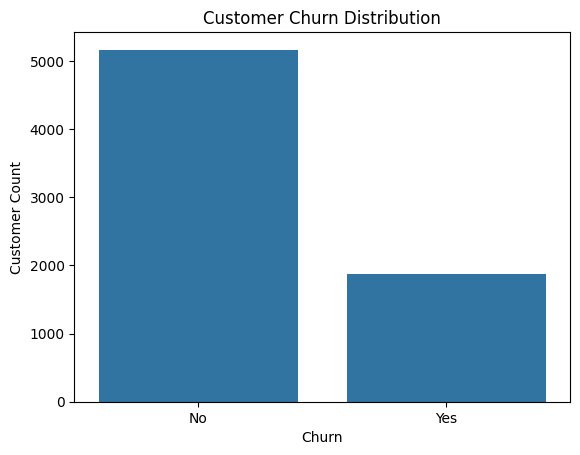

In [ ]:
sns.countplot(data=df, x='Churn')

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Customer Count")

plt.show()

Insights
*   This visualization shows the distribution of churned and retained customers.
*   Helps understand overall churn imbalance in the dataset.



Contract Type vs Churn

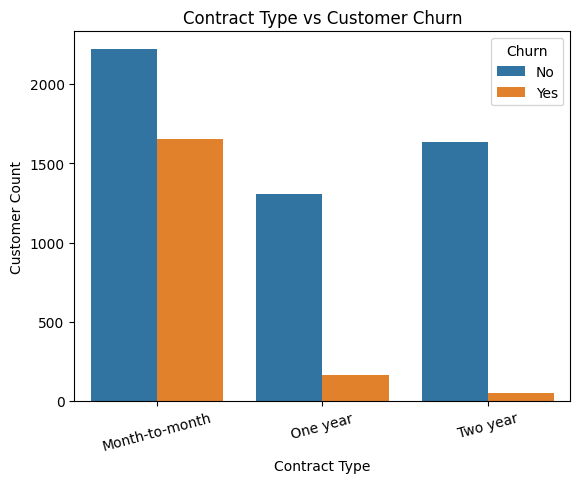

In [ ]:
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title("Contract Type vs Customer Churn")

plt.xlabel("Contract Type")

plt.ylabel("Customer Count")

plt.xticks(rotation=15)

plt.show()

Insights


*   Customers with month-to-month contracts are more likely to churn.
*   Long-term contracts show better customer retention.



Monthly Charges Distribution

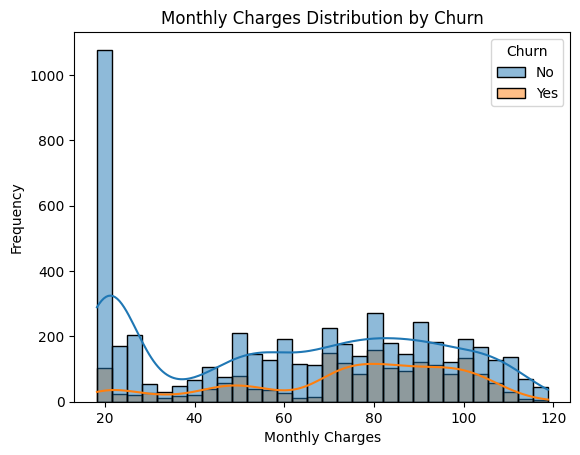

In [ ]:
sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    kde=True,
    bins=30
)

plt.title("Monthly Charges Distribution by Churn")

plt.xlabel("Monthly Charges")

plt.ylabel("Frequency")

plt.show()

Insights


*  Customers with higher monthly charges show increased churn probability.
*   Pricing may influence customer retention behavior.



Tenure vs Monthly Charges

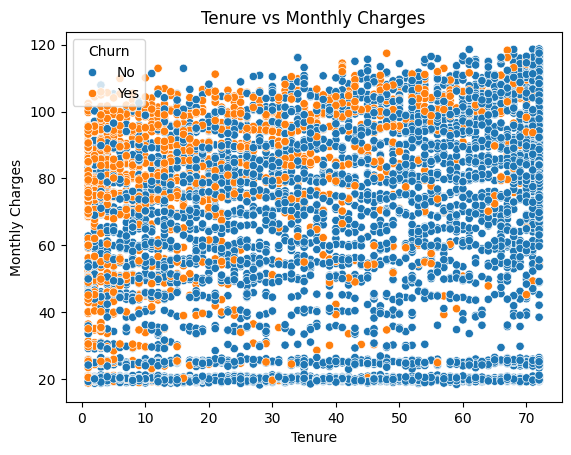

In [ ]:
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn'
)

plt.title("Tenure vs Monthly Charges")

plt.xlabel("Tenure")

plt.ylabel("Monthly Charges")

plt.show()

Insights


* Customers with lower tenure are more likely to churn.
*   Long-term customers generally show better retention patterns.


Correlation Heatmap

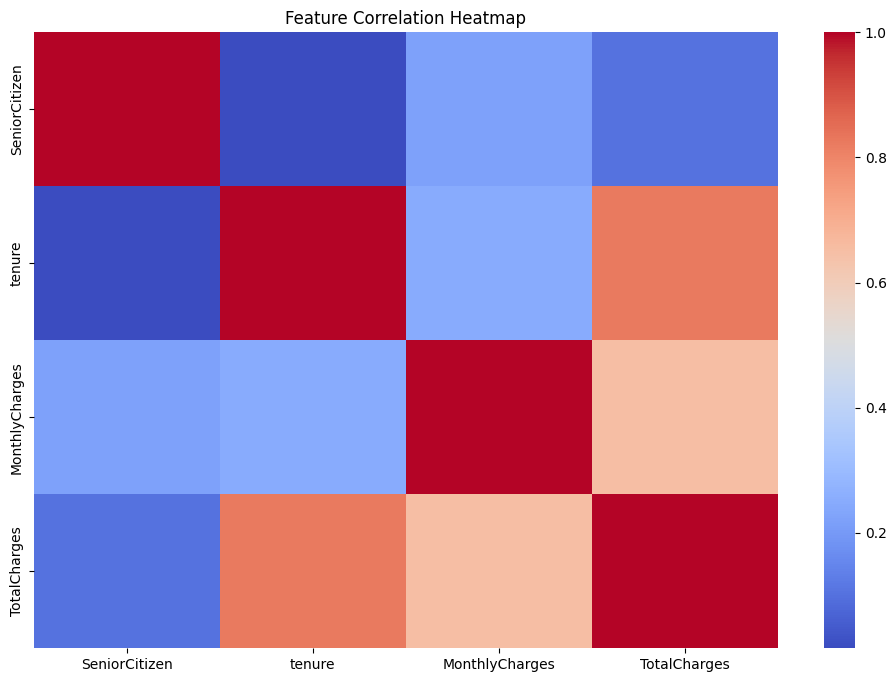

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)--

plt.title("Feature Correlation Heatmap")

plt.show()

Insights


*   Displays relationships between numerical variables.
*   Helps identify features strongly associated with churn.



# **Feature Engineering & Data Preprocessing**

Objective

Convert categorical variables into numerical format and prepare the dataset for machine learning model training.

Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

Insights


*   Binary categorical variables were converted into numerical format.
*   Machine learning models require numerical input data.


One-Hot Encoding

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        'InternetService',
        'MultipleLines',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract',
        'PaymentMethod'
    ],
    drop_first=True
)

Insights


*   One-Hot Encoding converts multi-category columns into numerical dummy variables.
*   drop_first=True helps avoid multicollinearity.



Verify Transformed Dataset

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


Dataset Information After Encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7032 non-null   object 
 1   gender                                 7032 non-null   int64  
 2   SeniorCitizen                          7032 non-null   int64  
 3   Partner                                7032 non-null   int64  
 4   Dependents                             7032 non-null   int64  
 5   tenure                                 7032 non-null   int64  
 6   PhoneService                           7032 non-null   int64  
 7   PaperlessBilling                       7032 non-null   int64  
 8   MonthlyCharges                         7032 non-null   float64
 9   TotalCharges                           7032 non-null   float64
 10  Churn                                  7032 non-null   int64  
 11  Inte

Insights


*   All categorical variables are now converted into machine-learning-compatible numerical format.
*   Dataset is now ready for feature selection and model training.


Define Features & Target Variable

In [ ]:
X = df.drop(['Churn', 'customerID'], axis=1)

y = df['Churn']

Insights


*   X contains input features used for prediction.
*   y contains the target variable (Churn).


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Insights


*   Training data is used for model learning.
*   Testing data is used for evaluating model performance.
*   80-20 split helps maintain balanced evaluation.





# **Model Building — Logistic Regression**

**Objective**

Train a Logistic Regression model to predict customer churn and evaluate its performance using classification metrics.

Import Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

Train Logistic Regression Model

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Insights


*   Logistic Regression is a supervised machine learning algorithm used for binary classification.
*   The model learns patterns associated with customer churn behavior.


Generate Predictions

In [ ]:
y_pred = log_model.predict(X_test)

Insights


*   Predictions are generated using unseen test data
*   Output values:

      0 → Customer Retained
      
      1 → Customer Churned



Model Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.7860696517412935


Insights


*   Accuracy measures the percentage of correctly predicted records.
*   Higher accuracy indicates better prediction performance.



Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[913 120]
 [181 193]]


Insights


*   Confusion Matrix evaluates:

       Correct Predictions

       Incorrect Predictions

       False Positives
    
       False Negatives




Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Insights


*   Precision → Prediction accuracy for positive class

*   Recall → Ability to identify actual churn cases

* F1-Score → Balance between Precision and Recall



Confusion Matrix Visualization

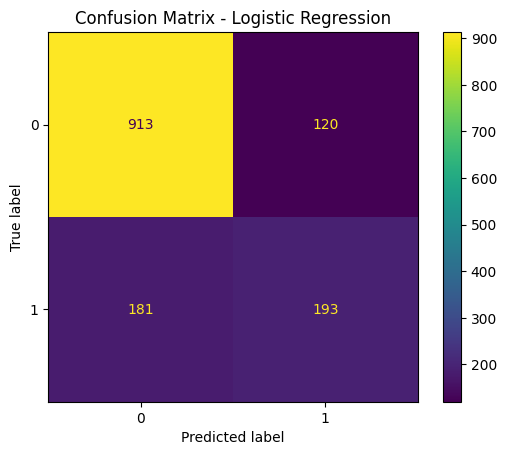

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

Insights


*   Visual representation of prediction performance.
*   Helps understand model classification quality more clearly.


# **Model Building — Random Forest Classifier**

Objective

Train a Random Forest model to improve churn prediction performance using ensemble learning techniques.

Import Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Train Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Insights


*   Random Forest combines multiple decision trees for prediction.
*  Ensemble learning helps improve model accuracy and reduce overfitting.



Generate Predictions

In [ ]:
rf_pred = rf_model.predict(X_test)

Insights


*   Predictions are generated using test data.
*   Used to evaluate model performance on unseen records.

Random Forest Accuracy

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7889125799573561


Insights


*   Accuracy measures overall prediction correctness.
*   Random Forest generally performs better on complex datasets.

Random Forest Confusion Matrix

In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[932 101]
 [196 178]]


Insights

*   Helps evaluate:

    correctly classified customers

    false churn predictions
    
    missed churn cases

Random Forest Classification Report

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



Insights


*   Evaluates model performance using:


     *   Precision
     *   Recall

     *   F1-Score


*   Useful for understanding churn prediction quality.


Confusion Matrix Visualization

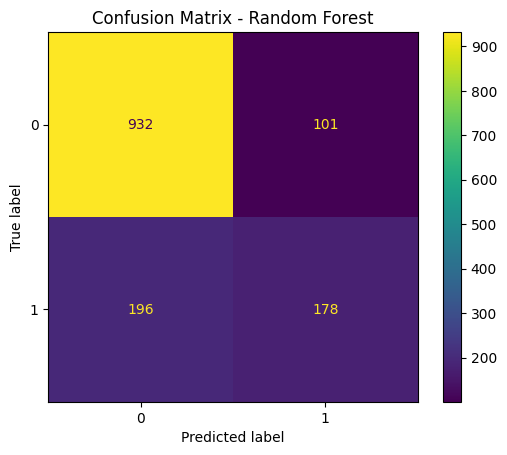

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Random Forest")

plt.show()

Insights


*   Provides a visual understanding of prediction performance.
*   Helps compare model effectiveness against Logistic Regression.


Feature Importance Analysis

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,TotalCharges,0.196076
4,tenure,0.173389
7,MonthlyCharges,0.168924
9,InternetService_Fiber optic,0.041026
28,PaymentMethod_Electronic check,0.034535
0,gender,0.027531
14,OnlineSecurity_Yes,0.026124
6,PaperlessBilling,0.025395
26,Contract_Two year,0.024494
20,TechSupport_Yes,0.024201


Insights


*   Identifies the most influential features affecting customer churn.
*   Helps businesses focus on key churn-driving factors.

Visualize Top Features

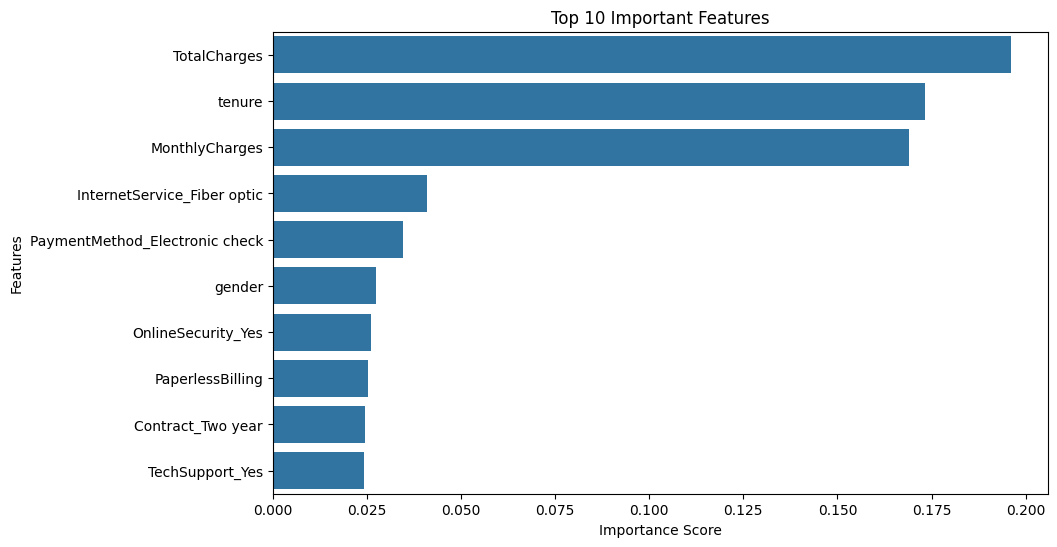

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

Insights


*   Visualizes the top factors contributing to customer churn.
*   Useful for business decision-making and retention strategy planning.

# **Final Business Insights & Recommendations**

Key Findings:
- Customers with month-to-month contracts showed higher churn probability.
- Higher monthly charges were associated with increased churn risk.
- Customers with shorter tenure were more likely to leave the service.
- Contract type and payment methods significantly influenced customer retention.

Business Recommendations:
- Introduce discounts for long-term subscription plans.
- Create loyalty programs for new customers.
- Target high-risk customers using retention campaigns.
- Improve customer engagement strategies for short-tenure users.

Conclusion:
The project successfully analyzed customer churn behavior using exploratory data analysis and machine learning models. Random Forest demonstrated stronger predictive capability and identified critical churn-driving factors that can support customer retention strategies.